# The House Price Prediction Model 
### 1. Problem Statement
#### Predict the selling price of a house based on its physical characteristics and location using supervised machine learning regression algorithms.
##### It's a Regression Problem because the data is continuous

## Data set : 
#### For this Project the Ames Housing Dataset is used
###### The Ames Housing Dataset is a well-known dataset in the field of machine learning and data analysis. It contains various features and attributes of residential homes in Ames, Iowa, USA. 
###### Number of Instances: The dataset consists of 2,930 instances or observations.
###### Number of Features: There are 79 different features or variables that describe various aspects of the residential properties.
###### Target Variable: The target variable in the dataset is the "SalePrice," representing the sale price of the houses.
###### Data Types: The features include both numerical and categorical variables, covering a wide range of aspects such as lot size, number of rooms, location, construction, and more.

In [1]:
# All the imports
# Numerical Computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from catboost import CatBoostRegressor

import joblib

# 2. Loading Data

In [2]:
#Loading Dataset
data = pd.read_csv("../data/AmesHousing.csv")
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# 3. Exploratory Data Analysis (EDA)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [4]:
data.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [5]:
data.shape

(2930, 82)

In [6]:
data.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [7]:
# Missing Values
missing = (
    data.isnull()
        .sum()
        .sort_values(ascending=False)
)

missing = missing[missing > 0]

print(missing)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Yr Blt      159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
Garage Cars          1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
BsmtFin SF 2         1
Garage Area          1
dtype: int64


In [8]:
missing_percent = (
    data.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

print(missing_percent)

Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Cond        5.426621
Garage Finish      5.426621
Garage Yr Blt      5.426621
Garage Qual        5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Qual          2.730375
Bsmt Cond          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
BsmtFin SF 1       0.034130
Garage Cars        0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
BsmtFin SF 2       0.034130
Garage Area        0.034130
dtype: float64


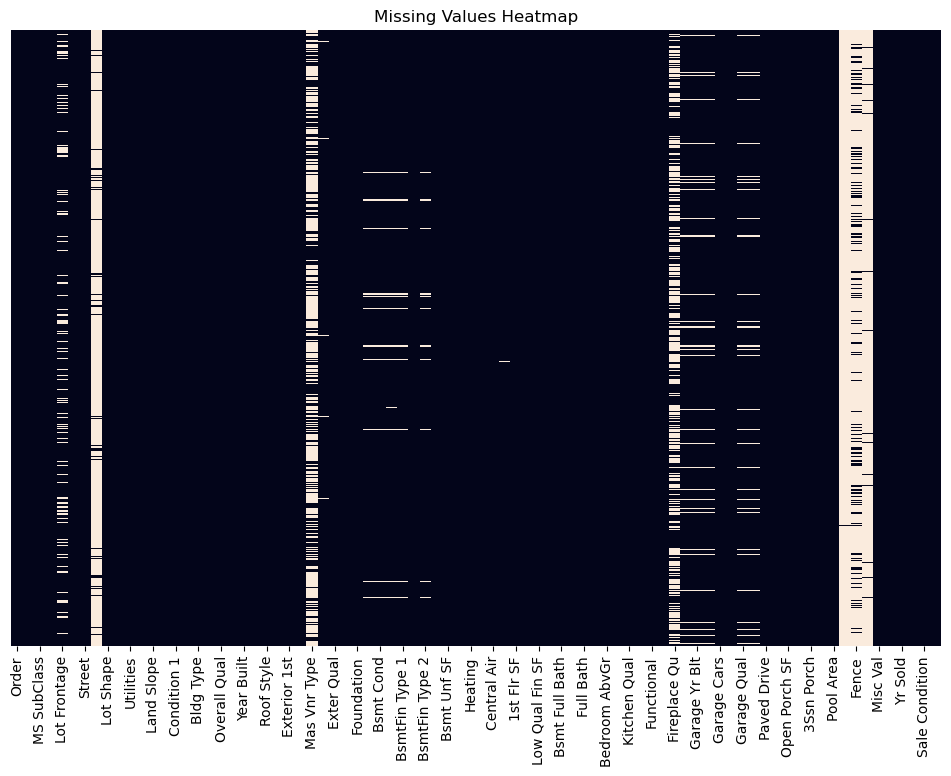

In [9]:
# Visualizing missing values
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    data.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

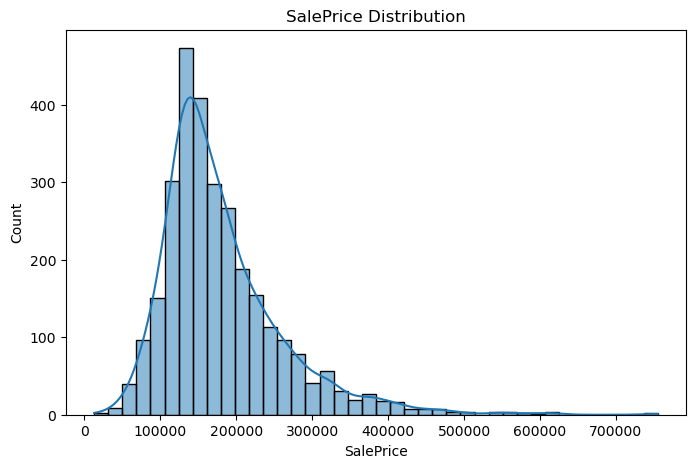

In [10]:
#Explore the Target Variable
plt.figure(figsize=(8,5))

sns.histplot(
    data["SalePrice"],
    bins=40,
    kde=True
)

plt.title("SalePrice Distribution")

plt.show()

### Statistical Analysis of the Target Variable

Before building any machine learning model, it is important to understand the statistical properties of the target variable (`SalePrice`).

In this section, we will:

- Calculate the skewness of the target variable.
- Examine whether the distribution is approximately normal.
- Decide whether a logarithmic transformation may be required later.

Understanding the distribution of the target variable helps us choose appropriate preprocessing techniques and improve model performance.

In [11]:
# Calculate the skewness of the target variable

saleprice_skew = data["SalePrice"].skew()

print(f"Skewness of SalePrice: {saleprice_skew:.3f}")

Skewness of SalePrice: 1.744


### Detecting Outliers

Outliers are observations that are significantly different from the majority of the data.

Visualizing outliers helps us determine whether extremely expensive houses may influence model training.

In this section, a boxplot is used to identify unusually high or low sale prices.

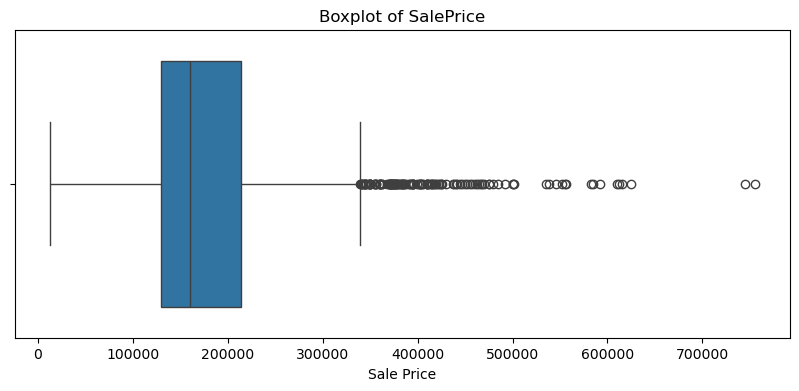

In [12]:
# Visualize outliers in SalePrice

plt.figure(figsize=(10,4))

sns.boxplot(
    x=data["SalePrice"]
)

plt.title("Boxplot of SalePrice")

plt.xlabel("Sale Price")

plt.show()

### Correlation Analysis

Correlation measures the strength of the relationship between numerical features and the target variable.

Features with higher positive or negative correlations are generally more useful for prediction.

This analysis helps us identify the most influential variables affecting house prices.

In [13]:
# Compute correlation matrix

correlation_matrix = data.corr(numeric_only=True)

# Correlation with SalePrice

saleprice_corr = correlation_matrix["SalePrice"].sort_values(
    ascending=False
)

print(saleprice_corr)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

### Features Most Correlated with SalePrice

The following analysis highlights the numerical features that have the strongest positive correlation with the target variable.

These features are likely to have the greatest impact on predicting house prices.

In [14]:
# Top 15 features most correlated with SalePrice

top_corr = saleprice_corr.head(15)

print(top_corr)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64


### Correlation Heatmap

A heatmap provides a visual representation of the correlation between the most influential numerical features.

This visualization makes it easier to identify strong positive or negative relationships between variables.

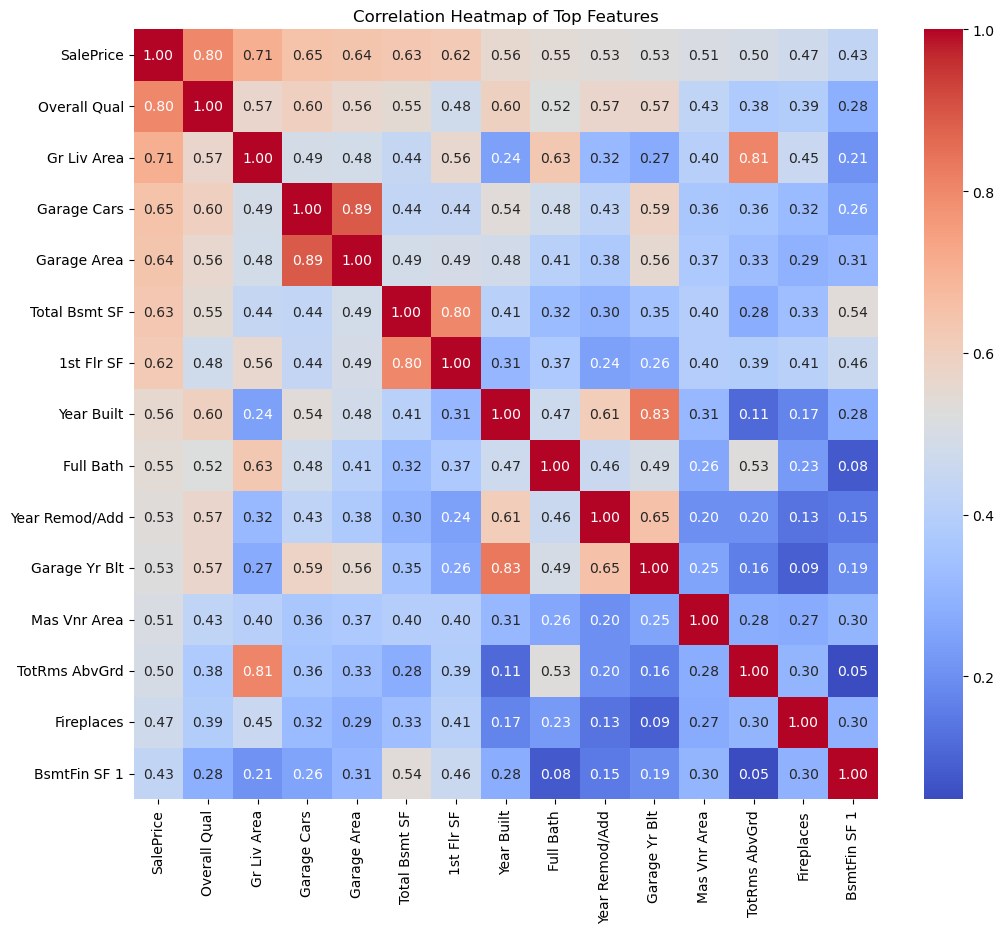

In [15]:
# Select the 15 most correlated numerical features

top_features = saleprice_corr.head(15).index

plt.figure(figsize=(12,10))

sns.heatmap(
    data[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top Features")

plt.show()

###  Relationship Between Key Features and SalePrice

After identifying the features most correlated with the target variable, the next step is to examine their relationships visually.

Scatter plots and boxplots help us identify trends, detect outliers, and understand whether the relationship between a feature and the sale price is linear or non-linear. These insights are useful before feature engineering and model training.

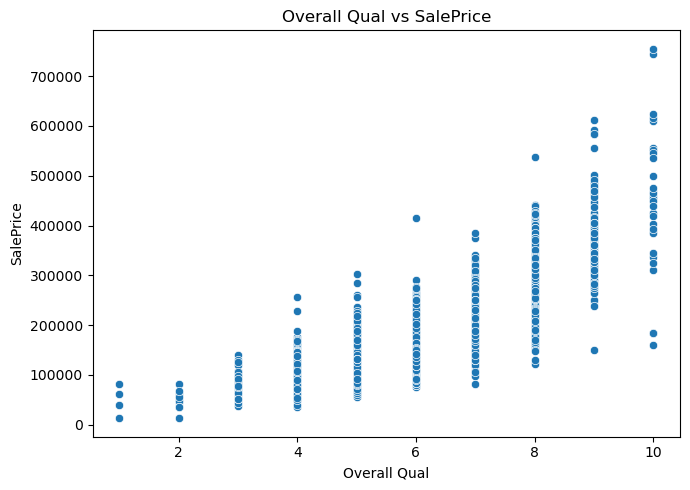

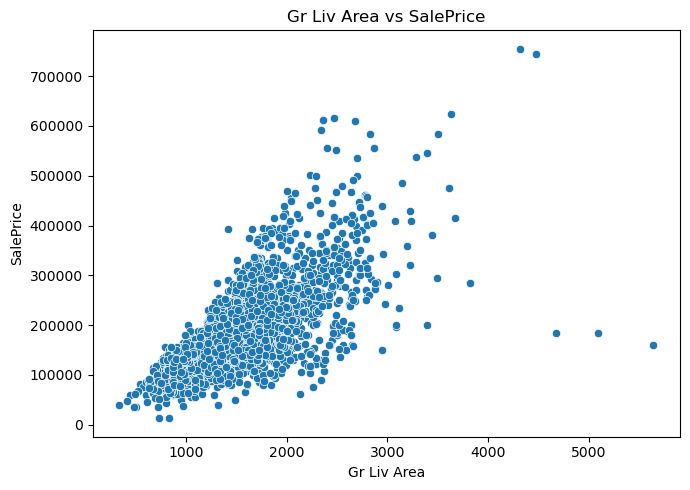

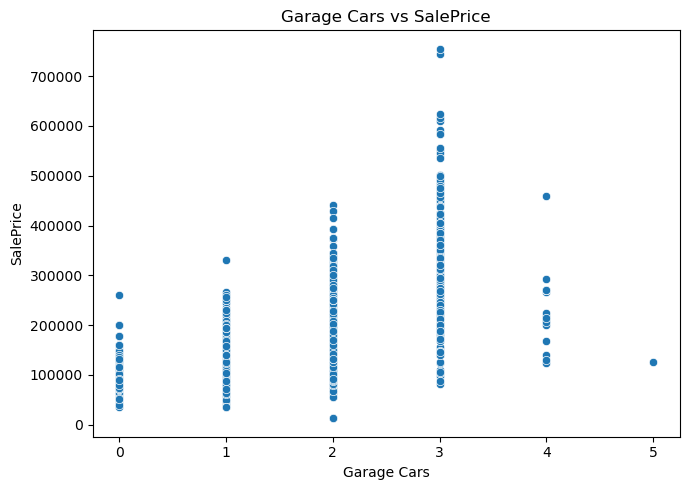

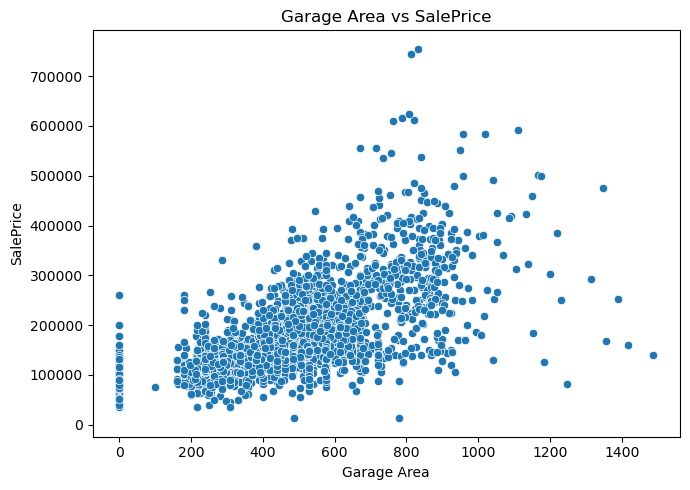

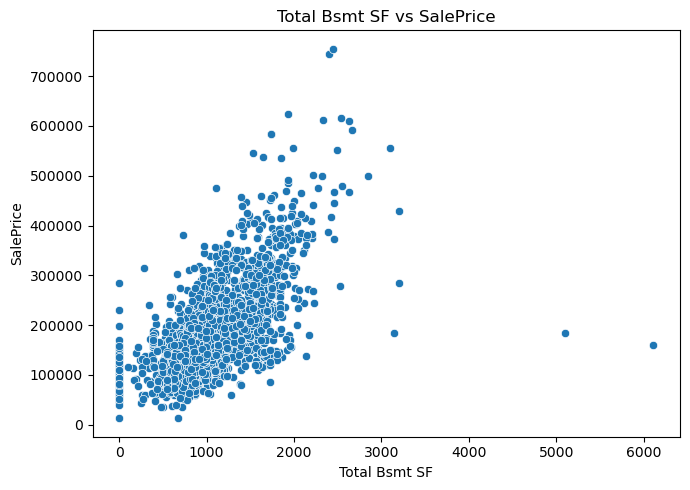

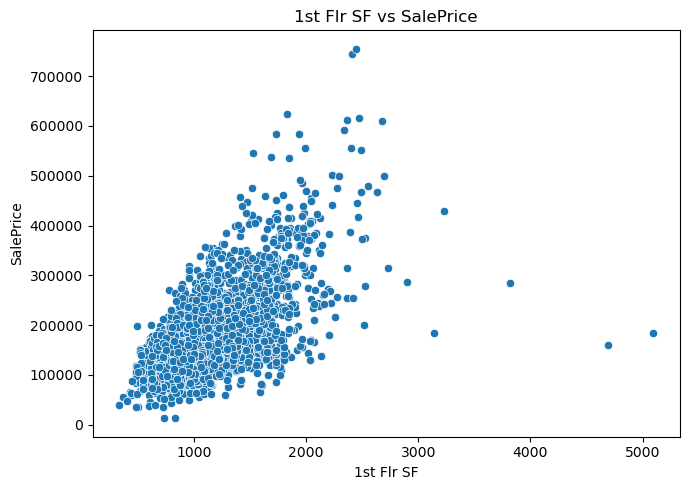

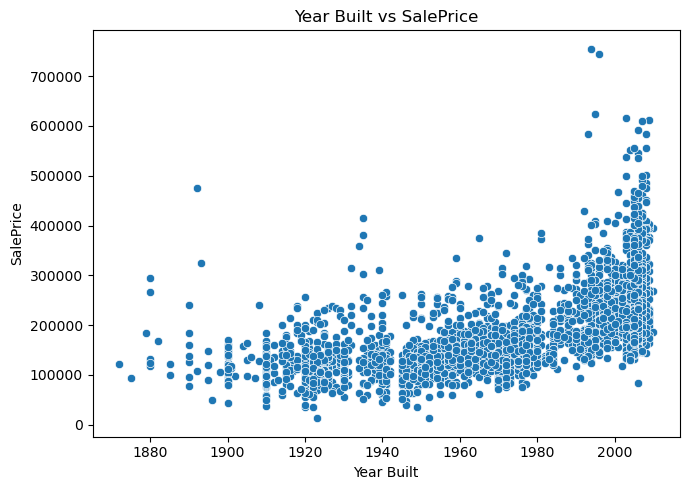

In [16]:
# Features with strong correlation to SalePrice
important_features = [
    "Overall Qual",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area",
    "Total Bsmt SF",
    "1st Flr SF",
    "Year Built"
]

# Create scatter plots
for feature in important_features:
    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=data,
        x=feature,
        y="SalePrice"
    )

    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")

    plt.tight_layout()
    plt.show()

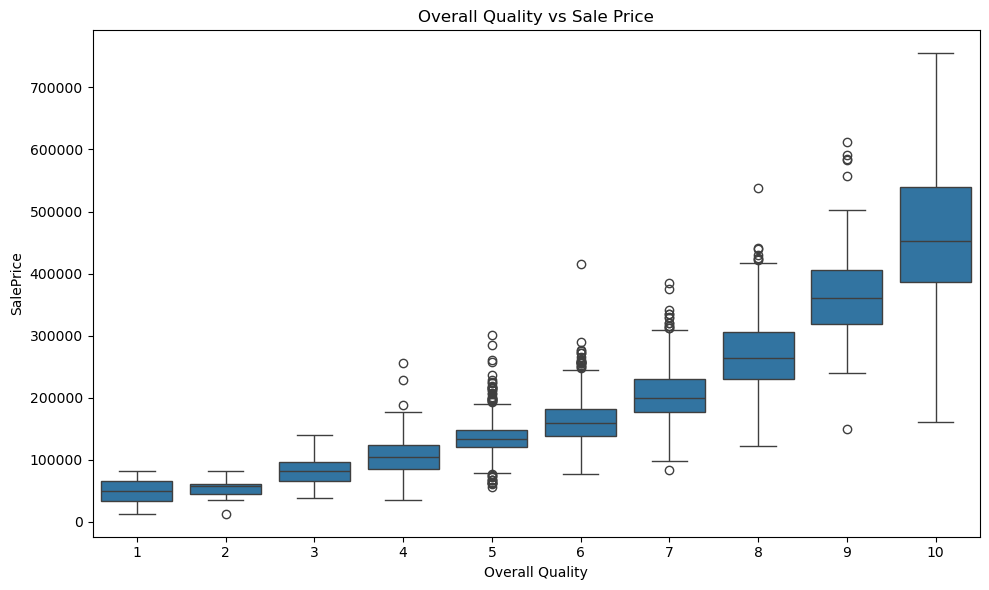

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="Overall Qual",
    y="SalePrice"
)

plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")

plt.tight_layout()
plt.show()

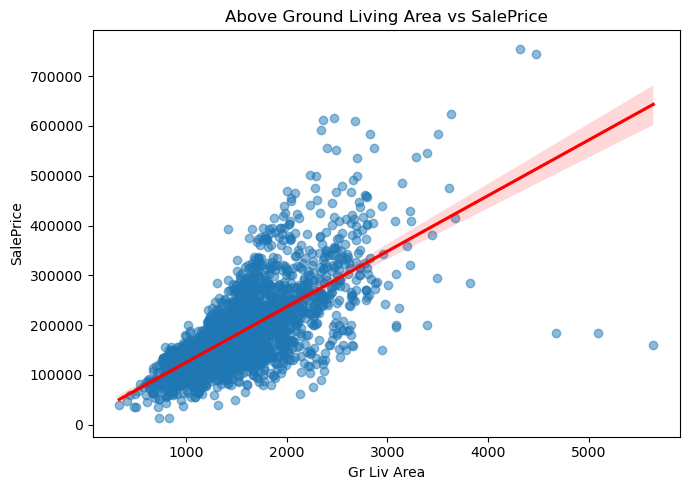

In [18]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=data,
    x="Gr Liv Area",
    y="SalePrice",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Above Ground Living Area vs SalePrice")

plt.tight_layout()
plt.show()

### Key Observations

- Houses with higher overall quality generally have higher sale prices.
- Larger living areas tend to increase the sale price.
- Garage capacity and garage area show a positive relationship with house prices.
- A small number of observations appear to be potential outliers and will be reviewed during the preprocessing stage.
- These visualizations confirm that several numerical features have meaningful predictive power.

# 4. Data Cleaning & Preprocessing

The Ames Housing dataset contains missing values across both numerical and categorical features. Instead of applying a single imputation method, different strategies are used depending on the meaning of each feature.

- Features where `NaN` represents the absence of a property (e.g., no garage, no basement, no pool) are replaced with `"None"` or `0` where appropriate.
- Numerical features with genuine missing values are imputed using the median.
- Categorical features with genuine missing values are imputed using the most frequent category.

This feature-specific approach preserves meaningful information while preparing the dataset for machine learning.

In [19]:
# Features where NaN means the property does not exist
none_features = [
    "Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu",
    "Garage Type", "Garage Finish", "Garage Qual", "Garage Cond",
    "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
    "BsmtFin Type 1", "BsmtFin Type 2"
]

# Replace missing categorical values with "None"
for feature in none_features:
    data[feature] = data[feature].fillna("None")

# Garage year missing because the house has no garage
data["Garage Yr Blt"] = data["Garage Yr Blt"].fillna(0)

# Masonry veneer
data["Mas Vnr Type"] = data["Mas Vnr Type"].fillna("None")
data["Mas Vnr Area"] = data["Mas Vnr Area"].fillna(0)

# Numerical features
numerical_features = [
    "Lot Frontage",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "Garage Cars",
    "Garage Area"
]

for feature in numerical_features:
    data[feature] = data[feature].fillna(data[feature].median())

# Remaining categorical features
data["Electrical"] = data["Electrical"].fillna(
    data["Electrical"].mode()[0]
)

In [20]:
# Verify that all missing values have been handled
print("Remaining Missing Values:", data.isnull().sum().sum())

Remaining Missing Values: 0


# 5. Feature Engineering

Feature engineering is the process of creating new variables from existing features to better represent the underlying characteristics of the data.

In [21]:
# Create a copy for feature engineering
data_fe = data.copy()

# House age at the time of sale
data_fe["HouseAge"] = data_fe["Yr Sold"] - data_fe["Year Built"]

# Years since last remodeling
data_fe["RemodAge"] = data_fe["Yr Sold"] - data_fe["Year Remod/Add"]


In [22]:
# Total bathroom score
data_fe["TotalBathrooms"] = (
    data_fe["Full Bath"] +
    (0.5 * data_fe["Half Bath"]) +
    data_fe["Bsmt Full Bath"] +
    (0.5 * data_fe["Bsmt Half Bath"])
)

# Total porch area
data_fe["TotalPorchSF"] = (
    data_fe["Open Porch SF"] +
    data_fe["Enclosed Porch"] +
    data_fe["3Ssn Porch"] +
    data_fe["Screen Porch"]
)

# Total outdoor area
data_fe["TotalOutdoorSF"] = (
    data_fe["Wood Deck SF"] +
    data_fe["TotalPorchSF"]
)

# Total living space
data_fe["TotalLivingSF"] = (
    data_fe["Gr Liv Area"] +
    data_fe["Total Bsmt SF"]
)

print("New features created successfully.")

New features created successfully.


In [23]:
# Remove identifier columns

data_fe.drop(
    columns=["Order", "PID"],
    inplace=True
)

In [24]:
# Separate features and target

X = data_fe.drop("SalePrice", axis=1)
y = data_fe["SalePrice"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (2930, 85)
Target Shape : (2930,)


In [25]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numerical Features : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features : 42
Categorical Features : 43


### Preprocessing Pipeline

Machine learning algorithms require numerical input. The preprocessing pipeline automates feature encoding and ensures that the same transformations are consistently applied during both training and inference.

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

## Train-Test Split

The dataset is divided into training and testing sets to evaluate how well the model generalizes to unseen data.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (2344, 85)
Testing Set  : (586, 85)


# 6. Model Training

Multiple regression models are trained to predict house prices.

Each model is combined with the preprocessing pipeline to ensure that the same feature transformations are applied consistently during both training and inference. This approach reduces the risk of data leakage and creates a reproducible machine learning workflow.

The following models are evaluated:

- Linear Regression (Baseline)
- Random Forest Regressor
- CatBoost Regressor

### Model Evaluation Function

To keep the notebook concise and reusable, a helper function is created to evaluate each model using common regression metrics.

In [29]:
from sklearn.pipeline import Pipeline

def evaluate_model(model_name, pipeline, X_test, y_test):

    # Predict
    predictions = pipeline.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)

    print("=" * 50)
    print(model_name)
    print("=" * 50)
    print(f"R² Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"MAE      : {mae:.2f}")

    return {
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    }

## Linear Regression

Linear Regression serves as the baseline model. Although it assumes a linear relationship between features and the target variable, it provides a useful benchmark for comparing more advanced algorithms.

In [30]:
# Linear Regression Pipeline

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

# Evaluate
lr_results = evaluate_model(
    "Linear Regression",
    lr_pipeline,
    X_test,
    y_test
)

Linear Regression
R² Score : 0.8880
RMSE     : 29961.95
MAE      : 17353.05


## Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees. It can model complex non-linear relationships while reducing overfitting through bootstrap aggregation.

In [31]:
# Random Forest Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Evaluate
rf_results = evaluate_model(
    "Random Forest",
    rf_pipeline,
    X_test,
    y_test
)

Random Forest
R² Score : 0.9197
RMSE     : 25371.82
MAE      : 15545.04


## CatBoost Regressor

CatBoost is a gradient boosting algorithm designed to work efficiently with structured tabular data. It generally performs well on datasets containing both numerical and categorical features.

In [32]:
# CatBoost Pipeline

cat_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", CatBoostRegressor(
        verbose=0,
        random_state=42
    ))
])

# Train
cat_pipeline.fit(X_train, y_train)

# Evaluate
cat_results = evaluate_model(
    "CatBoost",
    cat_pipeline,
    X_test,
    y_test
)

CatBoost
R² Score : 0.9441
RMSE     : 21176.54
MAE      : 12765.20


## Model Comparison

The performance of all trained models is summarized using the coefficient of determination (R²), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE).

In [33]:
results = pd.DataFrame([
    lr_results,
    rf_results,
    cat_results
])

results = results.sort_values(
    by="R2",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,R2,RMSE,MAE
0,CatBoost,0.944067,21176.540006,12765.196880
1,Random Forest,0.919710,25371.819354,15545.037036
2,Linear Regression,0.888031,29961.945541,17353.048810


In [34]:
best_model = results.iloc[0]

print("Best Model")
print(best_model)

Best Model
Model        CatBoost
R2           0.944067
RMSE     21176.540006
MAE       12765.19688
Name: 0, dtype: object


# 7. Hyperparameter Tuning

The baseline CatBoost model already provides strong predictive performance. In this section, hyperparameter tuning is performed to search for a better combination of model parameters and potentially improve generalization performance.

`RandomizedSearchCV` is used instead of `GridSearchCV` because it is more computationally efficient for larger search spaces while still exploring a diverse set of parameter combinations.

In [35]:
from sklearn.model_selection import RandomizedSearchCV

# Parameter search space
param_dist = {
    "model__iterations": [300, 500, 700, 1000],
    "model__depth": [4, 6, 8, 10],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__l2_leaf_reg": [1, 3, 5, 7, 9],
    "model__bagging_temperature": [0, 1, 3, 5]
}

In [36]:
random_search = RandomizedSearchCV(
    estimator=cat_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [37]:
# Train and search for the best parameters
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['MS '
                                                                                'SubClass',
                                                                                'Lot '
                                                                                'Frontage',
                                                                                'Lot '
                                                                                'Area',
                                                                                'Overall '
                                                                                'Qual',
                                                                                'Overall '
                                                                                'Cond',
                                                                                'Year '
                                                                                'Built',
                                                                                'Year '
                                                                                'Remod/Add',
                                                                                'Mas '
                                                                                'Vnr '
                                                                                'Area',
                                                                                'BsmtFin '
                                                                                'SF '
                                                                                '1',
                                                                                'BsmtFin '
                                                                                'SF '
                                                                                '2',
                                                                                'Bsmt '
                                                                                'Unf '
                                                                                'SF',
                                                                                'Total '...
                                                                                'Electrical', ...])])),
                                             ('model',
                                              CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__bagging_temperature': [0, 1, 3,
                                                                       5],
                                        'model__depth': [4, 6, 8, 10],
                                        'model__iterations': [300, 500, 700,
                                                              1000],
                                        'model__l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1]},
                   random_state=42, scoring='r2', verbose=2)

In [38]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation R²:")
print(random_search.best_score_)

Best Parameters:
{'model__learning_rate': 0.05, 'model__l2_leaf_reg': 3, 'model__iterations': 700, 'model__depth': 8, 'model__bagging_temperature': 1}

Best Cross-Validation R²:
0.912301062879199


In [39]:
# Best tuned pipeline
best_cat_pipeline = random_search.best_estimator_

# Evaluate tuned model
cat_tuned_results = evaluate_model(
    "CatBoost Tuned",
    best_cat_pipeline,
    X_test,
    y_test
)

CatBoost Tuned
R² Score : 0.9349
RMSE     : 22851.87
MAE      : 13416.95


In [41]:
comparison_tuned = pd.DataFrame([
    cat_results,
    cat_tuned_results
])

comparison_tuned

,Model,R2,RMSE,MAE
0,CatBoost,0.944067,21176.540006,12765.196880
1,CatBoost Tuned,0.934867,22851.873839,13416.953579


# 8. Cross-Validation

A single train-test split provides one estimate of model performance, but the result can vary depending on how the data is divided.

Cross-validation evaluates the model across multiple train-test splits, providing a more reliable measure of its ability to generalize to unseen data. This helps assess both the average performance and the stability of the model.

In [45]:
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross Validation
best_pipeline = random_search.best_estimator_
cv_scores = cross_val_score(
    estimator=best_pipeline,
    X=X,
    y=y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [46]:
print(cv_scores)
print(cv_scores.mean())
print(cv_scores.std())

[0.9211234  0.94269576 0.9182831  0.86403404 0.9332315 ]
0.9158735605634515
0.027354821570825315


In [47]:
print("Cross Validation Scores")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

Cross Validation Scores
Fold 1: 0.9211
Fold 2: 0.9427
Fold 3: 0.9183
Fold 4: 0.8640
Fold 5: 0.9332


In [48]:
print(f"\nMean R² : {cv_scores.mean():.4f}")
print(f"Standard Deviation : {cv_scores.std():.4f}")


Mean R² : 0.9159
Standard Deviation : 0.0274


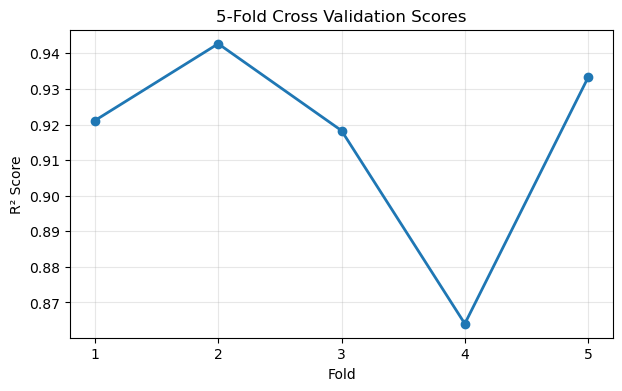

In [50]:
#Visualize Cross-Validation Scores
plt.figure(figsize=(7,4))

plt.plot(
    range(1, 6),
    cv_scores,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 6))
plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("5-Fold Cross Validation Scores")

plt.grid(alpha=0.3)

plt.show()

# 9. Feature Importance

Understanding which features influence the model's predictions is an important part of model interpretation.

Feature importance measures the relative contribution of each feature to the prediction process. This helps identify the factors that most strongly affect house prices and provides valuable insights into the dataset.

In [51]:
cat_model = best_pipeline.named_steps["model"]

In [53]:
#tranforming feature names
feature_names = best_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

In [54]:
importance = cat_model.feature_importances_

In [55]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [56]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)